<u><b>2. Car Price Prediction Dashboard   
Problem: 
Develop an interface to predict used car prices using features like year, fuel type, and mileage. 


<u><b>Step 1: Install Libraries

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn streamlit

Note: you may need to restart the kernel to use updated packages.


<u><b>Step 2: Load and Clean Dataset

In [3]:
import pandas as pd

data = pd.read_csv("Car Prdecit data .csv")

print(data.head())

data.dropna(inplace=True)

     Year  Mileage FuelType     Price
0  2018.0  30000.0   Petrol  600000.0
1  2017.0  40000.0   Diesel  550000.0
2  2020.0  15000.0   Petrol  850000.0
3  2019.0  25000.0   Diesel  700000.0
4  2016.0  50000.0   Petrol  450000.0


<u><b>Step 3: Convert Fuel Type to Numeric

In [4]:
data = pd.get_dummies(data,
                      columns=['FuelType'],
                      drop_first=True)

print(data.head())

     Year  Mileage     Price  FuelType_Petrol
0  2018.0  30000.0  600000.0             True
1  2017.0  40000.0  550000.0            False
2  2020.0  15000.0  850000.0             True
3  2019.0  25000.0  700000.0            False
4  2016.0  50000.0  450000.0             True


<u><b>Step 4: Split Features and Target

In [7]:
X = data.drop("Price", axis=1)
y = data["Price"]

<u><b>Step 5: Train Regression Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<u><b>Step 6: Feature Importance Visualization

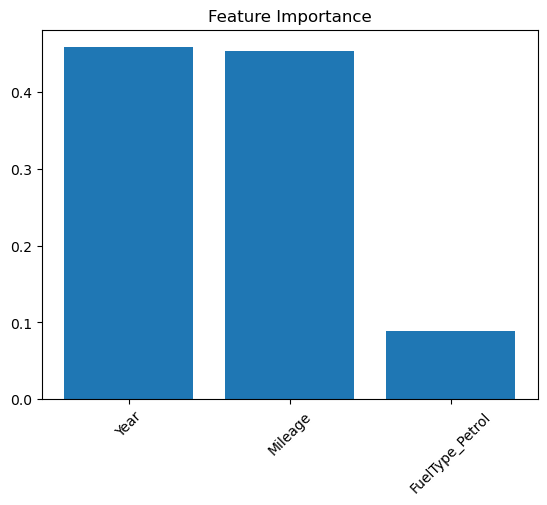

In [10]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

<u><B>Step 7: Create Streamlit Dashboard

In [11]:
import streamlit as st
import pandas as pd

st.title("Car Price Prediction Dashboard")

year = st.number_input("Year", 2010, 2025, 2020)
mileage = st.number_input("Mileage", 0, 200000, 20000)

fuel = st.selectbox(
    "Fuel Type",
    ["Petrol", "Diesel"]
)

fuel_diesel = 1 if fuel == "Diesel" else 0

input_data = pd.DataFrame({
    "Year":[year],
    "Mileage":[mileage],
    "FuelType_Petrol":[0],
    "FuelType_Diesel":[fuel_diesel]
})

if st.button("Predict Price"):
    price = model.predict(input_data)
    st.success(f"Predicted Price: ₹ {price[0]:,.0f}")

2026-06-04 14:41:43.084 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.439 
  command:

    streamlit run C:\Users\shyam\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-04 14:41:45.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.443 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.448 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.449 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:41:45.455 Thread 'MainThread': mi

<u><b>Step 8: Add Chart in Dashboard

In [12]:
st.subheader("Dataset Overview")

st.bar_chart(data["Price"])

2026-06-04 14:42:43.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:42:43.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:42:43.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:42:45.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:42:45.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 14:42:45.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

<u><b>Step 9: Run Dashboard

In [17]:
!streamlit run car_dashboard.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: car_dashboard.py
